In [74]:
comparison = pd.DataFrame(results)
summary = comparison.groupby("method").agg({
    "density": ["mean", "std"],
    "avg_degree": ["mean", "std"],
    "components": ["mean", "std"],
    "largest_component": ["mean", "std"],
    "clustering": ["mean", "std"],
    "efficiency": ["mean", "std"],
    "path_length": ["mean", "std"]
})
summary

density           avg_degree           components           \
                  mean       std       mean       std       mean      std   
method                                                                      
MST+PT        0.200000  0.000000  37.800000  0.000000   1.000000  0.00000   
Proportional  0.200000  0.000000  37.800000  0.000000   1.114837  0.94712   
kNN           0.239996  0.009751  45.359227  1.843004   1.000000  0.00000   

             largest_component           clustering           efficiency  \
                          mean       std       mean       std       mean   
method                                                                     
MST+PT              190.000000  0.000000   0.474875  0.040709   0.582710   
Proportional        189.874267  1.107153   0.474948  0.040898   0.583063   
kNN                 190.000000  0.000000   0.436623  0.028670   0.619076   

                       path_length            
                   std        mean       std  
method                                        
MST+PT        0.013737    1.906275  0.096459  
Proportional  0.012294    1.903881  0.081964  
kNN           0.004654    1.765534  0.010913

In [75]:
comparison.groupby("method")["components"].value_counts().unstack(fill_value=0)

components,1,2,3,4,5,6,8,14,26
method,,,,,,,,,
MST+PT,1193,0,0,0,0,0,0,0,0
Proportional,1137,34,8,6,3,1,2,1,1
kNN,1193,0,0,0,0,0,0,0,0


In [76]:
site_summary = comparison.groupby(
    ["method", "site"]
).agg({
    "density": "mean",
    "components": "mean",
    "clustering": "mean",
    "efficiency": "mean",
    "path_length": "mean"
})
site_summary

density  components  clustering  efficiency  \
method       site                                                       
MST+PT       KKI         0.200000    1.000000    0.446381    0.589036   
             NYU         0.200000    1.000000    0.474028    0.583337   
             NeuroIMAGE  0.200000    1.000000    0.463327    0.583568   
             OHSU        0.200000    1.000000    0.490389    0.578590   
             Peking_1    0.200000    1.000000    0.460079    0.587765   
             Peking_2    0.200000    1.000000    0.475386    0.583630   
             Peking_3    0.200000    1.000000    0.476023    0.583842   
             Pittsburgh  0.200000    1.000000    0.498581    0.576632   
             WashU       0.200000    1.000000    0.465921    0.583775   
Proportional KKI         0.200000    1.000000    0.446381    0.589036   
             NYU         0.200000    1.081218    0.474086    0.583621   
             NeuroIMAGE  0.200000    1.562500    0.463650    0.585521   
             OHSU        0.200000    1.181435    0.490523    0.579094   
             Peking_1    0.200000    1.023529    0.460084    0.587817   
             Peking_2    0.200000    1.074627    0.475407    0.583823   
             Peking_3    0.200000    1.071429    0.476040    0.584039   
             Pittsburgh  0.200000    1.147727    0.498701    0.577068   
             WashU       0.200000    1.080537    0.465944    0.583994   
kNN          KKI         0.237738    1.000000    0.412936    0.618525   
             NYU         0.239695    1.000000    0.436490    0.619050   
             NeuroIMAGE  0.238015    1.000000    0.430206    0.618125   
             OHSU        0.243048    1.000000    0.446244    0.620211   
             Peking_1    0.236392    1.000000    0.427771    0.617574   
             Peking_2    0.238834    1.000000    0.438612    0.618358   
             Peking_3    0.238870    1.000000    0.437787    0.618658   
             Pittsburgh  0.239634    1.000000    0.460422    0.618019   
             WashU       0.240944    1.000000    0.426707    0.619878   

                         path_length  
method       site                     
MST+PT       KKI            1.865949  
             NYU            1.902178  
             NeuroIMAGE     1.911470  
             OHSU           1.931779  
             Peking_1       1.873545  
             Peking_2       1.899276  
             Peking_3       1.897646  
             Pittsburgh     1.944133  
             WashU          1.899223  
Proportional KKI            1.865949  
             NYU            1.900147  
             NeuroIMAGE     1.895482  
             OHSU           1.928789  
             Peking_1       1.873309  
             Peking_2       1.898198  
             Peking_3       1.896566  
             Pittsburgh     1.941214  
             WashU          1.897984  
kNN          KKI            1.764327  
             NYU            1.765090  
             NeuroIMAGE     1.767280  
             OHSU           1.764831  
             Peking_1       1.767343  
             Peking_2       1.767523  
             Peking_3       1.765790  
             Pittsburgh     1.771152  
             WashU          1.762617

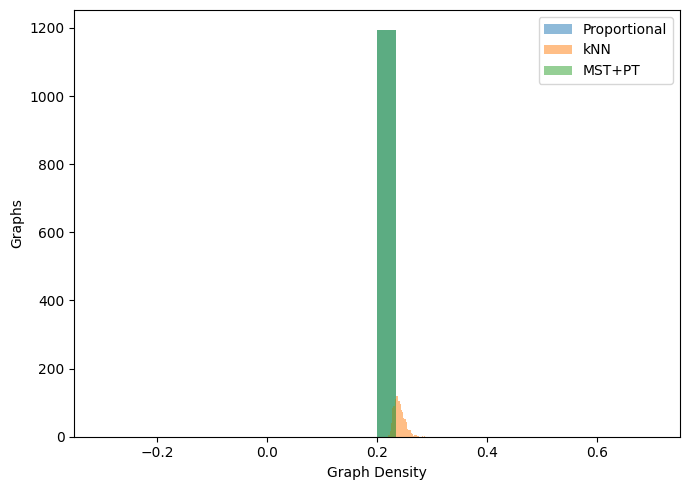

In [77]:
plt.figure(figsize=(7,5))
for method in comparison.method.unique():
    subset=comparison[
        comparison.method==method
    ]
    plt.hist(
        subset["density"],
        bins=30,
        alpha=0.5,
        label=method
    )
plt.legend()
plt.xlabel("Graph Density")
plt.ylabel("Graphs")
plt.tight_layout()
plt.show()

In [79]:
site_variation=(
    comparison
    .groupby(["method","site"])
    [["clustering",
      "efficiency",
      "path_length"]]
    .mean()
)

site_variation

clustering  efficiency  path_length
method       site                                           
MST+PT       KKI           0.446381    0.589036     1.865949
             NYU           0.474028    0.583337     1.902178
             NeuroIMAGE    0.463327    0.583568     1.911470
             OHSU          0.490389    0.578590     1.931779
             Peking_1      0.460079    0.587765     1.873545
             Peking_2      0.475386    0.583630     1.899276
             Peking_3      0.476023    0.583842     1.897646
             Pittsburgh    0.498581    0.576632     1.944133
             WashU         0.465921    0.583775     1.899223
Proportional KKI           0.446381    0.589036     1.865949
             NYU           0.474086    0.583621     1.900147
             NeuroIMAGE    0.463650    0.585521     1.895482
             OHSU          0.490523    0.579094     1.928789
             Peking_1      0.460084    0.587817     1.873309
             Peking_2      0.475407    0.583823     1.898198
             Peking_3      0.476040    0.584039     1.896566
             Pittsburgh    0.498701    0.577068     1.941214
             WashU         0.465944    0.583994     1.897984
kNN          KKI           0.412936    0.618525     1.764327
             NYU           0.436490    0.619050     1.765090
             NeuroIMAGE    0.430206    0.618125     1.767280
             OHSU          0.446244    0.620211     1.764831
             Peking_1      0.427771    0.617574     1.767343
             Peking_2      0.438612    0.618358     1.767523
             Peking_3      0.437787    0.618658     1.765790
             Pittsburgh    0.460422    0.618019     1.771152
             WashU         0.426707    0.619878     1.762617

In [80]:
site_variation.groupby(level=0).std()

,clustering,efficiency,path_length
method,,,
MST+PT,0.015758,0.003876,0.024722
Proportional,0.015780,0.003777,0.023553
kNN,0.013351,0.000866,0.002459


In [81]:
FINAL_METHOD="MST+PT"
FINAL_DENSITY=0.20
pd.DataFrame({
    "method":[FINAL_METHOD],
    "density":[FINAL_DENSITY]
}).to_csv(
DATA_ROOT/
"03_fc_matrices"/
"graph_construction_strategy.csv",
index=False
)
print("Graph construction finalized.")

Graph construction finalized.


## V4B

In [82]:
from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
from scipy.sparse.csgraph import minimum_spanning_tree

DATA_ROOT=Path("/home/nvidia/23BRS1236/adhd_data")
MANIFEST=DATA_ROOT/"03_fc_matrices"/"dynamic"/"dynamic_manifest.csv"

GRAPH_METHOD="MST_PT"
GRAPH_DENSITY=0.20
EDGE_SELECTION="absolute"
EDGE_WEIGHT="signed"

fc=sample[0]
N_ROI=fc.shape[0]
TOTAL_EDGES=N_ROI*(N_ROI-1)//2
TARGET_EDGES=int(GRAPH_DENSITY*TOTAL_EDGES)
upper_idx=np.triu_indices(N_ROI,1)
TARGET_EDGES=int(GRAPH_DENSITY*TOTAL_EDGES)

upper_idx=np.triu_indices(N_ROI,1)

print("Nodes:",N_ROI)
print("Possible edges:",TOTAL_EDGES)
print("Target edges:",TARGET_EDGES)

Nodes: 190
Possible edges: 17955
Target edges: 3591


In [83]:
manifest=pd.read_csv(MANIFEST)
print(manifest.shape)
manifest.head()

(1193, 10)


,subject_id,site,session,run,variant,timeseries_path,dynamic_fc_path,window,stride,n_windows
0,1018959,KKI,1,1,sfnwmrda,/home/nvidia/23BRS1236/adhd_data/02_timeseries...,/home/nvidia/23BRS1236/adhd_data/03_fc_matrice...,30,5,24
1,1019436,KKI,1,1,sfnwmrda,/home/nvidia/23BRS1236/adhd_data/02_timeseries...,/home/nvidia/23BRS1236/adhd_data/03_fc_matrice...,30,5,24
2,1043241,KKI,1,1,sfnwmrda,/home/nvidia/23BRS1236/adhd_data/02_timeseries...,/home/nvidia/23BRS1236/adhd_data/03_fc_matrice...,30,5,24
3,1266183,KKI,1,1,sfnwmrda,/home/nvidia/23BRS1236/adhd_data/02_timeseries...,/home/nvidia/23BRS1236/adhd_data/03_fc_matrice...,30,5,19
4,1535233,KKI,1,1,sfnwmrda,/home/nvidia/23BRS1236/adhd_data/02_timeseries...,/home/nvidia/23BRS1236/adhd_data/03_fc_matrice...,30,5,24


In [84]:
sample=np.load(
    manifest.dynamic_fc_path.iloc[0],
    mmap_mode="r"
)

print(sample.shape)
print(sample.dtype)

fc=sample[0]

print(fc.shape)
print(fc.min())
print(fc.max())

(24, 190, 190)
float32
(190, 190)
-0.9489486
1.0


In [85]:
def validate_fc(fc):
    assert fc.shape==(190,190)
    assert np.isfinite(fc).all()
    assert np.allclose(fc,fc.T,atol=1e-6)
    return True
validate_fc(fc)
print("Validation passed.")

Validation passed.


In [86]:
def preprocess_fc(fc):
    fc=((fc+fc.T)/2).astype(np.float32)
    np.fill_diagonal(fc,0)
    return fc
fc=preprocess_fc(fc)
print(fc.shape)
print(np.diag(fc)[:10])
print(fc.min(),fc.max())

(190, 190)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
-0.9489486 0.97676533


In [16]:
def build_graph(fc,density=0.20):
    fc=np.asarray(fc,dtype=np.float32)
    if fc.ndim!=2:
        raise ValueError("FC matrix must be 2D.")
    if fc.shape[0]!=fc.shape[1]:
        raise ValueError("FC matrix must be square.")
    if not np.isfinite(fc).all():
        raise ValueError("FC matrix contains NaN or Inf.")

    fc=(fc+fc.T)/2
    np.fill_diagonal(fc,0)
    n=fc.shape[0]
    total_edges=n*(n-1)//2
    target_edges=int(round(total_edges*density))
    abs_fc=np.abs(fc)
    G_full=nx.Graph()
    G_full.add_nodes_from(range(n))
    triu=np.triu_indices(n,1)
    for i,j in zip(*triu):
        G_full.add_edge(
            int(i),
            int(j),
            weight=float(abs_fc[i,j])
        )

    mst=nx.maximum_spanning_tree(
        G_full,
        algorithm="kruskal"
    )
    edge_mask=np.zeros((n,n),dtype=bool)
    for u,v in mst.edges():
        edge_mask[u,v]=True
        edge_mask[v,u]=True
    current_edges=mst.number_of_edges()
    rows=triu[0]
    cols=triu[1]
    abs_weights=abs_fc[rows,cols]
    order=np.lexsort(
        (
            cols,
            rows,
            -abs_weights
        )
    )

    for idx in order:
        if current_edges>=target_edges:
            break
        r=rows[idx]
        c=cols[idx]
        if edge_mask[r,c]:
            continue
        edge_mask[r,c]=True
        edge_mask[c,r]=True
        current_edges+=1
    edge_rows,edge_cols=np.where(np.triu(edge_mask,1))
    edge_weight=fc[edge_rows,edge_cols]
    edge_index=np.vstack(
        [
            edge_rows,
            edge_cols
        ]
    ).astype(np.int64)
    if edge_index.shape[1]!=target_edges:
        raise RuntimeError(
            f"Expected {target_edges} edges but obtained {edge_index.shape[1]}"
        )
    G_check=nx.Graph()
    G_check.add_nodes_from(range(n))
    G_check.add_edges_from(zip(edge_rows,edge_cols))

    if not nx.is_connected(G_check):
        raise RuntimeError("Graph is disconnected.")

    return edge_index,edge_weight.astype(np.float32)

In [88]:
edge_index,edge_weight=build_graph(fc)

print(edge_index.shape)
print(edge_weight.shape)

print("Edges :",edge_index.shape[1])
print("Expected :",TARGET_EDGES)

print("Weight Range")
print(edge_weight.min(),edge_weight.max())

(2, 3591)
(3591,)
Edges : 3591
Expected : 3591
Weight Range
-0.9489486 0.97676533


In [89]:
G=nx.Graph()

G.add_nodes_from(range(N_ROI))
for (u,v),w in zip(edge_index.T,edge_weight):
    G.add_edge(
        int(u),
        int(v),
        weight=float(w)
    )

print(nx.number_of_nodes(G))
print(nx.number_of_edges(G))
print(nx.is_connected(G))

190
3591
True
